In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

url = "https://huggingface.co/datasets/Solshine/CollegeOfAgricultureAndForestry_Agricultural_Crop_Dataset/resolve/main/Crop_recommendation.csv"
df = pd.read_csv(url)

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [2]:
locations = {
    "Ikeja (Lagos)": (6.60, 3.35),
    "Abeokuta (Ogun)": (7.15, 3.35),
    "Kano": (12.00, 8.52),
    "Kaduna": (10.52, 7.44),
    "Makurdi (Benue)": (7.73, 8.53),
    "Akure (Ondo)": (7.25, 5.19)
}

In [6]:
def get_climate(lat, lon):
    url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
    params = {
        "parameters": "T2M,RH2M,PRECTOTCORR",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "format": "JSON"
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    param_data = r.json()['properties']['parameter']
    return {
        "temperature": param_data['T2M']['ANN'],
        "humidity": param_data['RH2M']['ANN'],
        "rainfall_mm_per_day": param_data['PRECTOTCORR']['ANN'],
        "rainfall_annual_total": param_data['PRECTOTCORR']['ANN'] * 365
    }

In [7]:
climate_data = {}
for place, (lat, lon) in locations.items():
    climate_data[place] = get_climate(lat, lon)
    print(place, climate_data[place])

Ikeja (Lagos) {'temperature': 26.38, 'humidity': 85.81, 'rainfall_mm_per_day': 4.23, 'rainfall_annual_total': 1543.95}
Abeokuta (Ogun) {'temperature': 25.71, 'humidity': 86.43, 'rainfall_mm_per_day': 4.29, 'rainfall_annual_total': 1565.85}
Kano {'temperature': 26.6, 'humidity': 42.74, 'rainfall_mm_per_day': 1.72, 'rainfall_annual_total': 627.8}
Kaduna {'temperature': 24.34, 'humidity': 62.14, 'rainfall_mm_per_day': 3.83, 'rainfall_annual_total': 1397.95}
Makurdi (Benue) {'temperature': 25.92, 'humidity': 76.75, 'rainfall_mm_per_day': 3.37, 'rainfall_annual_total': 1230.05}
Akure (Ondo) {'temperature': 24.59, 'humidity': 83.53, 'rainfall_mm_per_day': 4.24, 'rainfall_annual_total': 1547.6000000000001}


In [8]:
results = []
assumed_soil = {"N": 80, "P": 45, "K": 40, "ph": 6.2}

for place, clim in climate_data.items():
    sample = pd.DataFrame([[
        assumed_soil["N"], assumed_soil["P"], assumed_soil["K"],
        clim["temperature"], clim["humidity"], assumed_soil["ph"], clim["rainfall_annual_total"]
    ]], columns=X.columns)

    prediction = model.predict(sample)[0]
    results.append({"location": place, **clim, "recommended_crop": prediction})

results_df = pd.DataFrame(results)
print(results_df)

          location  temperature  humidity  rainfall_mm_per_day  \
0    Ikeja (Lagos)        26.38     85.81                 4.23   
1  Abeokuta (Ogun)        25.71     86.43                 4.29   
2             Kano        26.60     42.74                 1.72   
3           Kaduna        24.34     62.14                 3.83   
4  Makurdi (Benue)        25.92     76.75                 3.37   
5     Akure (Ondo)        24.59     83.53                 4.24   

   rainfall_annual_total recommended_crop  
0                1543.95             rice  
1                1565.85             rice  
2                 627.80             rice  
3                1397.95             rice  
4                1230.05             rice  
5                1547.60             rice  


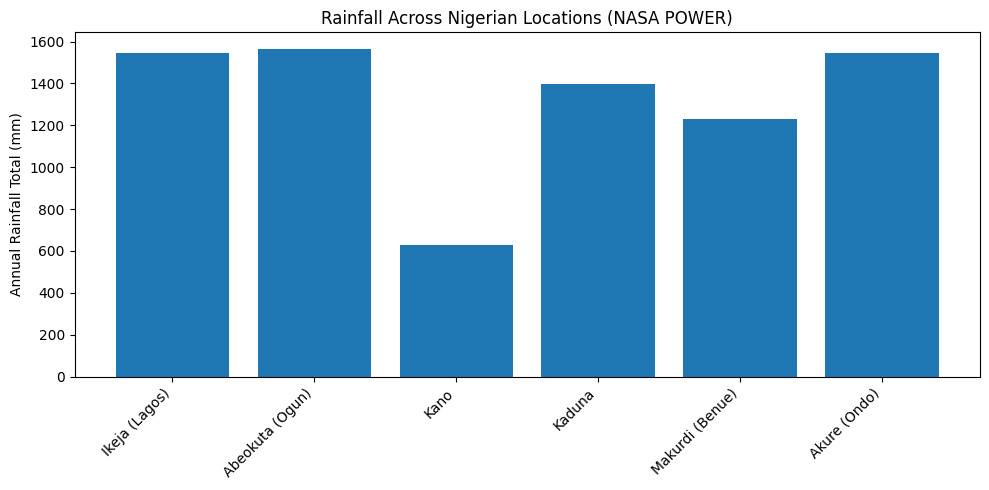

          location recommended_crop
0    Ikeja (Lagos)             rice
1  Abeokuta (Ogun)             rice
2             Kano             rice
3           Kaduna             rice
4  Makurdi (Benue)             rice
5     Akure (Ondo)             rice


In [9]:
plt.figure(figsize=(10,5))
plt.bar(results_df['location'], results_df['rainfall_annual_total'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Annual Rainfall Total (mm)')
plt.title('Rainfall Across Nigerian Locations (NASA POWER)')
plt.tight_layout()
plt.show()

print(results_df[['location', 'recommended_crop']])

In [10]:
print(results_df[['location', 'recommended_crop']])

          location recommended_crop
0    Ikeja (Lagos)             rice
1  Abeokuta (Ogun)             rice
2             Kano             rice
3           Kaduna             rice
4  Makurdi (Benue)             rice
5     Akure (Ondo)             rice
